Dataset Shape: (891, 15)

First 5 Rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ----

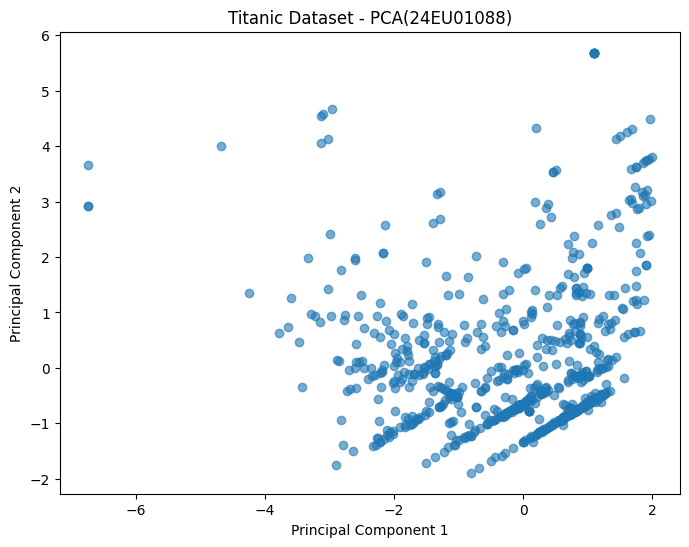


K-MEANS CLUSTERING


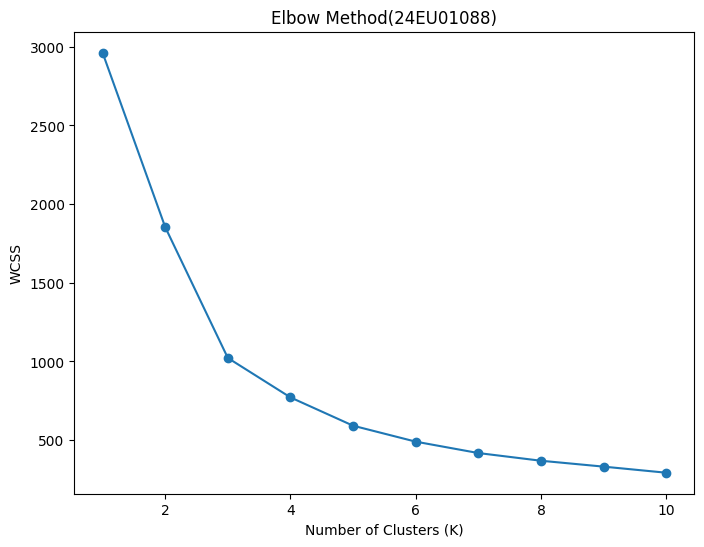


Cluster Labels:
[1 2 1 2 1 1 2 0 1 1 0 2 1 0 1 2 0 1 1 1]

PCA Data with Clusters:
        PC1       PC2  Cluster
0  1.140660 -0.076520        1
1 -1.768445  0.133479        2
2  0.879196 -0.726606        1
3 -1.458103  0.071555        2
4  0.561252 -0.943713        1

Silhouette Score: 0.5426487782732173


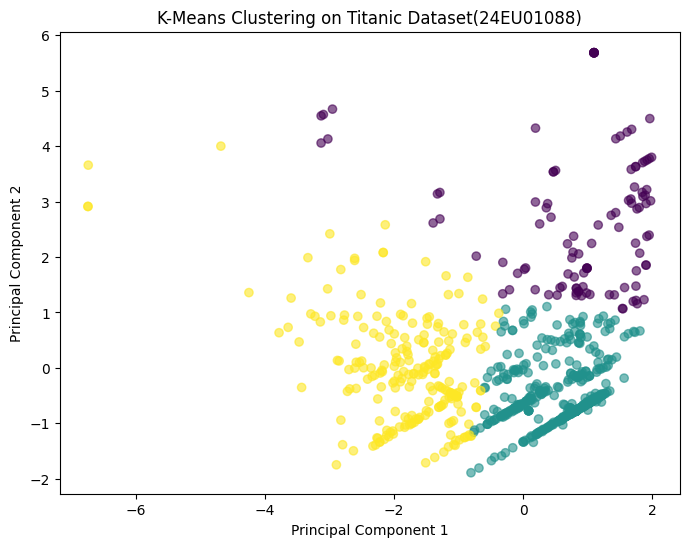


Cluster vs Survival:
Survived    0    1
Cluster           
0          60   46
1         391  159
2          98  137

Number of Samples in Each Cluster:
Cluster
0    106
1    550
2    235
Name: count, dtype: int64


In [ ]:
# ============================================================
# POST-LAB TASK: PCA AND CLUSTERING
# Dataset: Titanic Dataset
# ============================================================

# Step 1: Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# ============================================================
# Step 2: Load the Titanic Dataset
# ============================================================

titanic = sns.load_dataset("titanic")

print("Dataset Shape:", titanic.shape)

print("\nFirst 5 Rows:")
print(titanic.head())

print("\nDataset Information:")
print(titanic.info())


# ============================================================
# Step 3: Select Numerical Features
# ============================================================

# Select useful numerical features
features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

X = titanic[features].copy()

print("\nSelected Features:")
print(X.head())


# ============================================================
# Step 4: Handle Missing Values
# ============================================================

# Replace missing values with median
X = X.fillna(X.median())

print("\nMissing Values After Handling:")
print(X.isnull().sum())


# ============================================================
# Step 5: Feature Scaling
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nScaled Data:")
print(X_scaled[:5])


# ============================================================
# PART A: PCA
# ============================================================

print("\n========================================")
print("PCA")
print("========================================")

# Apply PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Display explained variance
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance:")
print(pca.explained_variance_ratio_.sum())


# ============================================================
# Step 6: Create PCA DataFrame
# ============================================================

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

print("\nPCA Data:")
print(pca_df.head())


# ============================================================
# Step 7: Visualize PCA
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Titanic Dataset - PCA(24EU01088)")

plt.show()


# ============================================================
# PART B: K-MEANS CLUSTERING
# ============================================================

print("\n========================================")
print("K-MEANS CLUSTERING")
print("========================================")


# ============================================================
# Step 8: Elbow Method
# ============================================================

wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_pca)

    wcss.append(kmeans.inertia_)


# Plot Elbow Curve
plt.figure(figsize=(8, 6))

plt.plot(
    range(1, 11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method(24EU01088)")

plt.show()


# ============================================================
# Step 9: Apply K-Means
# ============================================================

# Choose K = 3
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_pca)

print("\nCluster Labels:")
print(clusters[:20])


# ============================================================
# Step 10: Add Cluster Labels
# ============================================================

pca_df["Cluster"] = clusters

print("\nPCA Data with Clusters:")
print(pca_df.head())


# ============================================================
# Step 11: Silhouette Score
# ============================================================

silhouette = silhouette_score(
    X_pca,
    clusters
)

print("\nSilhouette Score:", silhouette)


# ============================================================
# Step 12: Visualize Clusters
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering on Titanic Dataset(24EU01088)")

plt.show()


# ============================================================
# Step 13: Compare Clusters with Survival
# ============================================================

result = pd.DataFrame({
    "Cluster": clusters,
    "Survived": titanic["survived"]
})

print("\nCluster vs Survival:")
print(
    pd.crosstab(
        result["Cluster"],
        result["Survived"]
    )
)

# ============================================================
# Step 14: Final Cluster Counts
# ============================================================

print("\nNumber of Samples in Each Cluster:")
print(
    pca_df["Cluster"].value_counts().sort_index()
)